# Combined Causal Analysis (Qwen + Gemma)

本 notebook 做四件事：
1. 合并 `evaluation.ipynb` 与 `evaluation_gemma.ipynb` 对应的输出，形成统一数据集。
2. 新增模型列（`model_group`, `is_gemma`）。
3. 用多种方法估计模型差异的因果效应。
4. 绘制 DAG，并做 SHAP (Shapley-style) 归因。

ATE 定义：`Gemma - Qwen`。

In [1]:
from __future__ import annotations

import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import statsmodels.formula.api as smf
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)
np.random.seed(42)


def resolve_path(candidates: list[str]) -> Path:
    for cand in candidates:
        p = Path(cand)
        if p.exists():
            return p.resolve()
    raise FileNotFoundError(f"Could not resolve any of: {candidates}")


QWEN_OUTPUT_PATH = resolve_path([
    "output/test_main_eval_stream_batch_Qwen__Qwen3-Next-80B-A3B-Instruct-FP8.jsonl",
    "../output/test_main_eval_stream_batch_Qwen__Qwen3-Next-80B-A3B-Instruct-FP8.jsonl",
])

GEMMA_OUTPUT_PATH = resolve_path([
    "output/test_main_eval_stream_batch_google__gemma-3-27b-it.jsonl",
    "../output/test_main_eval_stream_batch_google__gemma-3-27b-it.jsonl",
])

INPUT_PATH = resolve_path([
    "input/combined_dataset_with_reference_good_row_idx.json",
    "../input/combined_dataset_with_reference_good_row_idx.json",
])

ARTIFACT_DIR = resolve_path(["output", "../output"])


def _last_assistant_text(conv) -> str:
    if isinstance(conv, list):
        for msg in reversed(conv):
            if isinstance(msg, dict) and str(msg.get("role", "")).lower() == "assistant":
                return str(msg.get("content", "")).strip()
    return ""


VALID_PAIRWISE = {"A", "B", "C"}


def map_pairwise_to_gold_label(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().upper()
    if s == "A":
        return "model_a"
    if s == "B":
        return "model_b"
    if s == "C":
        return "tie"
    return np.nan


df_ref = pd.read_json(INPUT_PATH, lines=True)
df_ref = df_ref.copy()
df_ref["answer_a_text"] = df_ref["conversation_a"].map(_last_assistant_text)
df_ref["answer_b_text"] = df_ref["conversation_b"].map(_last_assistant_text)
df_ref["gold_winner"] = df_ref["winner"]

MERGE_COLS = ["row_idx", "dataset", "gold_winner", "reference_answer", "answer_a_text", "answer_b_text"]


def load_and_prepare(output_path: Path, model_group: str) -> pd.DataFrame:
    df_out = pd.read_json(output_path, lines=True)
    df_out = df_out.copy()
    df_out["model_group"] = model_group
    df_out["source_file"] = output_path.name

    df = df_out.merge(
        df_ref[MERGE_COLS],
        how="left",
        left_on="question_id",
        right_on="row_idx",
    )

    if "predicted_winner" not in df.columns:
        df["predicted_winner"] = pd.Series(index=df.index, dtype="object")
    if "format_error" not in df.columns:
        df["format_error"] = pd.Series(index=df.index, dtype="object")

    pair_mask = df["judge_type"].isin(["pairwise", "reference_guided"])
    df.loc[pair_mask, "winner_token"] = df.loc[pair_mask, "pairwise_winner"].astype(str).str.strip().str.upper()
    df.loc[pair_mask, "format_error"] = ~df.loc[pair_mask, "winner_token"].isin(VALID_PAIRWISE)
    df.loc[pair_mask, "predicted_winner"] = df.loc[pair_mask, "winner_token"].map(map_pairwise_to_gold_label)

    single_mask = df["judge_type"].eq("single_answer")
    sa = pd.to_numeric(df.loc[single_mask, "score_a"], errors="coerce")
    sb = pd.to_numeric(df.loc[single_mask, "score_b"], errors="coerce")
    valid_single = sa.notna() & sb.notna() & sa.between(1, 10) & sb.between(1, 10)

    single_pred = pd.Series(
        np.where(sa > sb, "model_a", np.where(sa < sb, "model_b", "tie")),
        index=df.index[single_mask],
        dtype="object",
    )
    single_pred.loc[~valid_single] = None

    df.loc[single_mask, "predicted_winner"] = single_pred
    df.loc[single_mask, "format_error"] = ~valid_single
    df["format_error"] = df["format_error"].fillna(True).astype(bool)

    df["agreement"] = np.where(
        df["predicted_winner"].notna() & df["gold_winner"].notna(),
        (df["predicted_winner"] == df["gold_winner"]).astype(float),
        np.nan,
    )
    df["error_rate"] = df["format_error"].astype(float)
    df["is_gemma"] = (df["model_group"] == "gemma").astype(int)
    return df


df_qwen = load_and_prepare(QWEN_OUTPUT_PATH, model_group="qwen")
df_gemma = load_and_prepare(GEMMA_OUTPUT_PATH, model_group="gemma")
df_all = pd.concat([df_qwen, df_gemma], ignore_index=True)


def one_flip_consistency(labels: list[str]) -> float:
    if len(labels) <= 1:
        return np.nan
    flips = sum(labels[i] != labels[i - 1] for i in range(1, len(labels)))
    return 1.0 - flips / (len(labels) - 1)


cons_rows = []
for key, g in df_all.groupby(["dataset", "model_group", "judge_model", "judge_type", "prompt_variant", "temperature", "question_id"], dropna=False):
    seq = g.sort_values("repeat_id")["predicted_winner"].dropna().astype(str).tolist()
    cons_rows.append(
        {
            "dataset": key[0],
            "model_group": key[1],
            "judge_model": key[2],
            "judge_type": key[3],
            "prompt_variant": key[4],
            "temperature": key[5],
            "question_id": key[6],
            "consistency_1flip": one_flip_consistency(seq),
        }
    )

df_cons = pd.DataFrame(cons_rows)
df_cons["is_gemma"] = (df_cons["model_group"] == "gemma").astype(int)

combined_path = ARTIFACT_DIR / "combined_judge_dataset_qwen_gemma.csv"
cons_path = ARTIFACT_DIR / "combined_judge_consistency_qwen_gemma.csv"
df_all.to_csv(combined_path, index=False)
df_cons.to_csv(cons_path, index=False)

print("Qwen rows :", len(df_qwen))
print("Gemma rows:", len(df_gemma))
print("All rows  :", len(df_all))
print("Model split:", df_all["model_group"].value_counts(dropna=False).to_dict())
print("Saved row-level data:", combined_path)
print("Saved consistency data:", cons_path)
display(df_all.head(3))
display(df_cons.head(3))

Qwen rows : 180000
Gemma rows: 180000
All rows  : 360000
Model split: {'qwen': 180000, 'gemma': 180000}
Saved row-level data: /home/snt/projects_lujun/LLMJudgeTempCausal/output/combined_judge_dataset_qwen_gemma.csv
Saved consistency data: /home/snt/projects_lujun/LLMJudgeTempCausal/output/combined_judge_consistency_qwen_gemma.csv


,run_key,question_id,model_a,model_b,human_winner,judge_model,judge_type,prompt_variant,temperature,repeat_id,seed,which_response,score_a,score_b,judge_reason_a,judge_reason_b,raw_output_a,raw_output_b,raw_output,judge_reason,pairwise_winner,model_group,source_file,row_idx,dataset,gold_winner,reference_answer,answer_a_text,answer_b_text,predicted_winner,format_error,winner_token,agreement,error_rate,is_gemma
0,0|pairwise|baseline|0.01|0,0,gpt-3.5-turbo,gpt-4,model_a,Qwen/Qwen3-Next-80B-A3B-Instruct-FP8,pairwise,baseline,0.01,0,478163327,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""judge_result"":""B""}",NaN,B,qwen,test_main_eval_stream_batch_Qwen__Qwen3-Next-8...,0,mt_bench_human_judgments,model_a,Yes. A simple way is to count words in each fi...,"Yes, we can parallelize the program using the ...","Yes, you can parallelize the program using the...",model_b,False,B,0.0,0.0,0
1,1|pairwise|baseline|0.01|0,1,llama-13b,vicuna-13b-v1.2,model_a,Qwen/Qwen3-Next-80B-A3B-Instruct-FP8,pairwise,baseline,0.01,0,478163327,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""judge_result"":""B""}",NaN,B,qwen,test_main_eval_stream_batch_Qwen__Qwen3-Next-8...,1,mt_bench_human_judgments,model_a,"In the second year, the startup invested half ...","The startup will invest $8,000 in software dev...",If the startup maintains the same strategy for...,model_b,False,B,0.0,0.0,0
2,2|pairwise|baseline|0.01|0,2,vicuna-13b-v1.2,gpt-3.5-turbo,model_b,Qwen/Qwen3-Next-80B-A3B-Instruct-FP8,pairwise,baseline,0.01,0,478163327,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""judge_result"":""B""}",NaN,B,qwen,test_main_eval_stream_batch_Qwen__Qwen3-Next-8...,2,mt_bench_human_judgments,model_b,"{""IPHONE"":""A"",""SAMSUNG GALAXY"":""A-"",""GOOGLE PI...","{\n""iPhone"": {\n""overall\_rating"": ""A""\n},\n""S...","Sure, here are the updated ratings in letter g...",model_b,False,B,1.0,0.0,0


,dataset,model_group,judge_model,judge_type,prompt_variant,temperature,question_id,consistency_1flip,is_gemma
0,mmlu_pro,gemma,google/gemma-3-27b-it,pairwise,baseline,0.01,350,1.0,1
1,mmlu_pro,gemma,google/gemma-3-27b-it,pairwise,baseline,0.01,351,1.0,1
2,mmlu_pro,gemma,google/gemma-3-27b-it,pairwise,baseline,0.01,352,1.0,1


## Causal DAG

Treatment:
- `is_gemma` (1=Gemma, 0=Qwen)

Outcomes:
- 行级 `agreement`, `error_rate`
- 题级 `consistency_1flip`

Adjustment set:
- `dataset`, `judge_type`, `prompt_variant`, `temperature`

假设这些可观测变量同时影响模型样本分布与最终指标，因此进行 backdoor 调整。

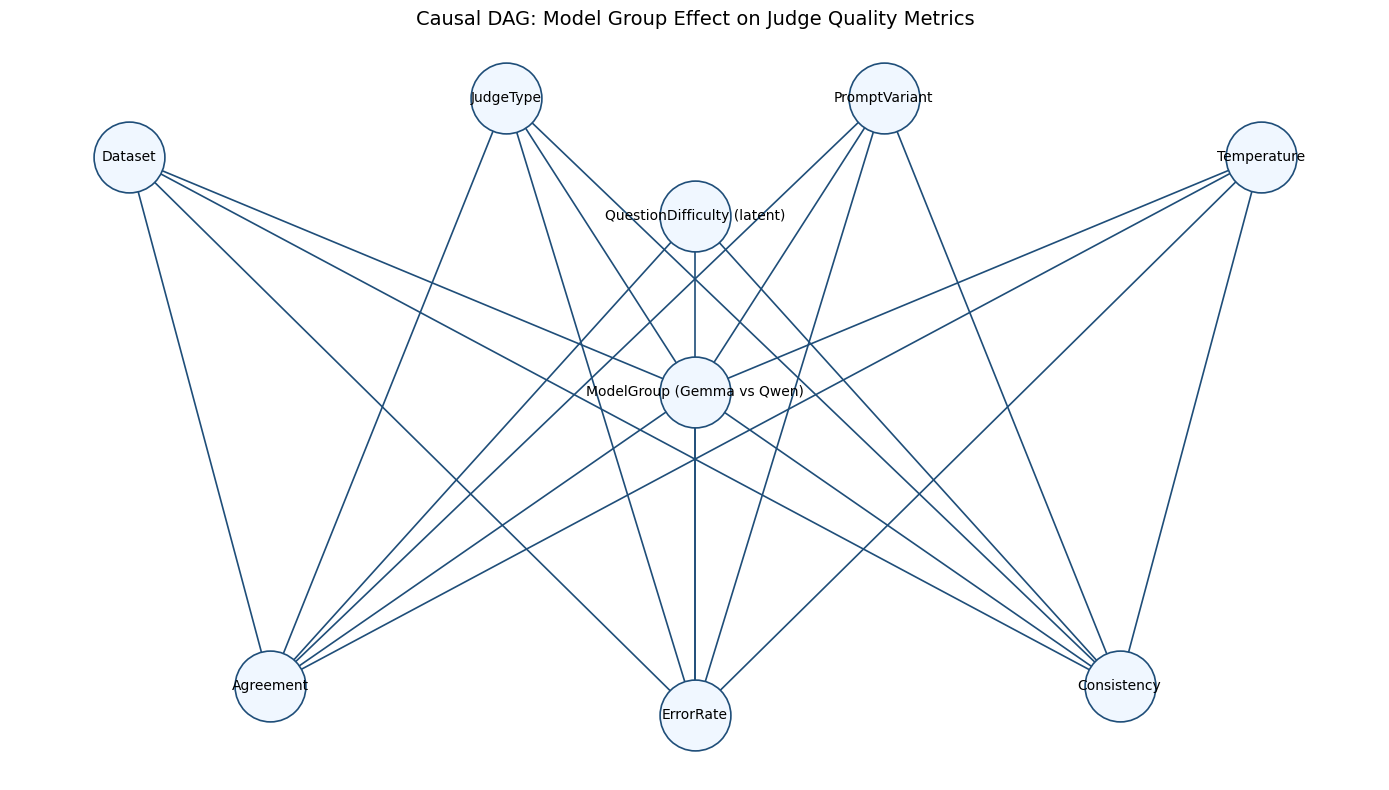

Saved DAG: /home/snt/projects_lujun/LLMJudgeTempCausal/output/causal_dag_qwen_gemma.png


In [2]:
G = nx.DiGraph()

nodes = [
    "Dataset",
    "JudgeType",
    "PromptVariant",
    "Temperature",
    "QuestionDifficulty (latent)",
    "ModelGroup (Gemma vs Qwen)",
    "Agreement",
    "ErrorRate",
    "Consistency",
]
G.add_nodes_from(nodes)

edges = [
    ("Dataset", "ModelGroup (Gemma vs Qwen)"),
    ("JudgeType", "ModelGroup (Gemma vs Qwen)"),
    ("PromptVariant", "ModelGroup (Gemma vs Qwen)"),
    ("Temperature", "ModelGroup (Gemma vs Qwen)"),

    ("Dataset", "Agreement"),
    ("Dataset", "ErrorRate"),
    ("Dataset", "Consistency"),
    ("JudgeType", "Agreement"),
    ("JudgeType", "ErrorRate"),
    ("JudgeType", "Consistency"),
    ("PromptVariant", "Agreement"),
    ("PromptVariant", "ErrorRate"),
    ("PromptVariant", "Consistency"),
    ("Temperature", "Agreement"),
    ("Temperature", "ErrorRate"),
    ("Temperature", "Consistency"),

    ("QuestionDifficulty (latent)", "Agreement"),
    ("QuestionDifficulty (latent)", "ErrorRate"),
    ("QuestionDifficulty (latent)", "Consistency"),

    ("ModelGroup (Gemma vs Qwen)", "Agreement"),
    ("ModelGroup (Gemma vs Qwen)", "ErrorRate"),
    ("ModelGroup (Gemma vs Qwen)", "Consistency"),
]
G.add_edges_from(edges)

pos = {
    "Dataset": (-1.2, 1.0),
    "JudgeType": (-0.4, 1.2),
    "PromptVariant": (0.4, 1.2),
    "Temperature": (1.2, 1.0),
    "QuestionDifficulty (latent)": (0.0, 0.8),
    "ModelGroup (Gemma vs Qwen)": (0.0, 0.2),
    "Agreement": (-0.9, -0.8),
    "ErrorRate": (0.0, -0.9),
    "Consistency": (0.9, -0.8),
}

plt.figure(figsize=(14, 8))
nx.draw_networkx_nodes(G, pos, node_size=2600, node_color="#f0f7ff", edgecolors="#1f4e79", linewidths=1.2)
nx.draw_networkx_labels(G, pos, font_size=10)
nx.draw_networkx_edges(G, pos, arrowstyle="-|>", arrowsize=16, width=1.2, edge_color="#1f4e79")
plt.title("Causal DAG: Model Group Effect on Judge Quality Metrics", fontsize=14)
plt.axis("off")
plt.tight_layout()
dag_path = ARTIFACT_DIR / "causal_dag_qwen_gemma.png"
plt.savefig(dag_path, dpi=220, bbox_inches="tight")
plt.show()
print("Saved DAG:", dag_path)

## Multi-method Causal Estimation

Methods:
1. Matched strata ATE
2. OLS adjustment
3. IPW
4. AIPW (doubly robust)

所有方法都在同一份整合数据上做对照，以检查估计稳健性。

In [3]:
CONTROL_COLS = ["dataset", "judge_type", "prompt_variant", "temperature"]


def _ci95(est: float, se: float) -> tuple[float, float]:
    lo = est - 1.96 * se
    hi = est + 1.96 * se
    return float(lo), float(hi)


def estimate_matched_ate(data: pd.DataFrame, outcome: str, key_cols: list[str]) -> dict:
    tmp = data[[*key_cols, "model_group", outcome]].dropna().copy()
    pivot = tmp.pivot_table(index=key_cols, columns="model_group", values=outcome, aggfunc="mean")
    if not {"gemma", "qwen"}.issubset(set(pivot.columns)):
        return {"method": "matched", "ate": np.nan, "se": np.nan, "ci_low": np.nan, "ci_high": np.nan, "n": 0}

    diff = (pivot["gemma"] - pivot["qwen"]).dropna()
    if len(diff) == 0:
        return {"method": "matched", "ate": np.nan, "se": np.nan, "ci_low": np.nan, "ci_high": np.nan, "n": 0}

    ate = float(diff.mean())
    se = float(diff.std(ddof=1) / math.sqrt(len(diff))) if len(diff) > 1 else 0.0
    ci_low, ci_high = _ci95(ate, se)
    return {"method": "matched", "ate": ate, "se": se, "ci_low": ci_low, "ci_high": ci_high, "n": int(len(diff))}


def estimate_regression_ate(data: pd.DataFrame, outcome: str) -> dict:
    tmp = data[[outcome, "is_gemma", *CONTROL_COLS]].dropna().copy()
    formula = f"{outcome} ~ is_gemma + C(dataset) + C(judge_type) + C(prompt_variant) + temperature"
    model = smf.ols(formula, data=tmp).fit(cov_type="HC3")
    ate = float(model.params.get("is_gemma", np.nan))
    se = float(model.bse.get("is_gemma", np.nan))
    ci_low, ci_high = _ci95(ate, se)
    return {"method": "regression_ols", "ate": ate, "se": se, "ci_low": ci_low, "ci_high": ci_high, "n": int(len(tmp))}


def _build_design_matrix(data: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    tmp = data[columns].copy()
    tmp["temperature"] = pd.to_numeric(tmp["temperature"], errors="coerce")
    tmp = pd.get_dummies(tmp, columns=["dataset", "judge_type", "prompt_variant"], drop_first=True)
    return tmp.fillna(0.0)


def estimate_ipw_ate(data: pd.DataFrame, outcome: str) -> dict:
    cols = [outcome, "is_gemma", *CONTROL_COLS]
    tmp = data[cols].dropna().copy()
    X = _build_design_matrix(tmp, CONTROL_COLS)
    t = tmp["is_gemma"].to_numpy().astype(float)
    y = tmp[outcome].to_numpy().astype(float)

    ps_model = LogisticRegression(max_iter=2000)
    ps_model.fit(X, t)
    e = ps_model.predict_proba(X)[:, 1]
    e = np.clip(e, 1e-3, 1 - 1e-3)

    w_t = t / e
    w_c = (1 - t) / (1 - e)

    mu1 = float(np.sum(w_t * y) / np.sum(w_t))
    mu0 = float(np.sum(w_c * y) / np.sum(w_c))
    ate = mu1 - mu0

    influence = w_t * (y - mu1) - w_c * (y - mu0)
    se = float(np.std(influence, ddof=1) / math.sqrt(len(tmp))) if len(tmp) > 1 else 0.0
    ci_low, ci_high = _ci95(ate, se)
    return {"method": "ipw", "ate": float(ate), "se": se, "ci_low": ci_low, "ci_high": ci_high, "n": int(len(tmp))}


def estimate_aipw_ate(data: pd.DataFrame, outcome: str) -> dict:
    cols = [outcome, "is_gemma", *CONTROL_COLS]
    tmp = data[cols].dropna().copy()
    X = _build_design_matrix(tmp, CONTROL_COLS)
    t = tmp["is_gemma"].to_numpy().astype(float)
    y = tmp[outcome].to_numpy().astype(float)

    ps_model = LogisticRegression(max_iter=2000)
    ps_model.fit(X, t)
    e = ps_model.predict_proba(X)[:, 1]
    e = np.clip(e, 1e-3, 1 - 1e-3)

    m1_model = RandomForestRegressor(n_estimators=220, random_state=42, n_jobs=-1, min_samples_leaf=20)
    m0_model = RandomForestRegressor(n_estimators=220, random_state=42, n_jobs=-1, min_samples_leaf=20)

    x1 = X.loc[t == 1]
    y1 = y[t == 1]
    x0 = X.loc[t == 0]
    y0 = y[t == 0]

    if len(x1) == 0 or len(x0) == 0:
        return {"method": "aipw", "ate": np.nan, "se": np.nan, "ci_low": np.nan, "ci_high": np.nan, "n": int(len(tmp))}

    m1_model.fit(x1, y1)
    m0_model.fit(x0, y0)

    m1 = m1_model.predict(X)
    m0 = m0_model.predict(X)

    psi = (m1 - m0) + t * (y - m1) / e - (1 - t) * (y - m0) / (1 - e)
    ate = float(np.mean(psi))
    se = float(np.std(psi, ddof=1) / math.sqrt(len(tmp))) if len(tmp) > 1 else 0.0
    ci_low, ci_high = _ci95(ate, se)
    return {"method": "aipw", "ate": ate, "se": se, "ci_low": ci_low, "ci_high": ci_high, "n": int(len(tmp))}


def run_all_methods(data: pd.DataFrame, outcome: str, matched_keys: list[str]) -> pd.DataFrame:
    rows = []
    rows.append(estimate_matched_ate(data, outcome, key_cols=matched_keys))
    rows.append(estimate_regression_ate(data, outcome))
    rows.append(estimate_ipw_ate(data, outcome))
    rows.append(estimate_aipw_ate(data, outcome))
    out = pd.DataFrame(rows)
    out.insert(0, "outcome", outcome)
    return out


matched_keys_row = ["dataset", "judge_type", "prompt_variant", "temperature", "question_id", "repeat_id"]
causal_agreement = run_all_methods(df_all, outcome="agreement", matched_keys=matched_keys_row)
causal_error = run_all_methods(df_all, outcome="error_rate", matched_keys=matched_keys_row)

matched_keys_cons = ["dataset", "judge_type", "prompt_variant", "temperature", "question_id"]
causal_consistency = run_all_methods(df_cons, outcome="consistency_1flip", matched_keys=matched_keys_cons)

causal_summary = pd.concat([causal_agreement, causal_error, causal_consistency], ignore_index=True)
causal_summary = causal_summary[["outcome", "method", "ate", "se", "ci_low", "ci_high", "n"]]

print("ATE = Gemma - Qwen")
display(causal_summary.sort_values(["outcome", "method"]).reset_index(drop=True))

causal_path = ARTIFACT_DIR / "causal_effects_qwen_vs_gemma.csv"
causal_summary.to_csv(causal_path, index=False)
print("Saved:", causal_path)

ATE = Gemma - Qwen


,outcome,method,ate,se,ci_low,ci_high,n
0,agreement,aipw,-0.009023,0.001687,-0.012329,-0.005717,344092
1,agreement,ipw,-0.009696,0.001693,-0.013015,-0.006378,344092
2,agreement,matched,-0.013745,0.001204,-0.016104,-0.011386,164569
3,agreement,regression_ols,-0.009815,0.001689,-0.013125,-0.006504,344092
4,consistency_1flip,aipw,0.053061,0.002231,0.048688,0.057434,35825
5,consistency_1flip,ipw,0.053000,0.002453,0.048192,0.057808,35825
6,consistency_1flip,matched,0.052792,0.002111,0.048654,0.056930,17825
7,consistency_1flip,regression_ols,0.052989,0.002249,0.048581,0.057397,35825
8,error_rate,aipw,-0.075411,0.000638,-0.076662,-0.074161,360000
9,error_rate,ipw,-0.075411,0.000673,-0.076731,-0.074091,360000


Saved: /home/snt/projects_lujun/LLMJudgeTempCausal/output/causal_effects_qwen_vs_gemma.csv


## SHAP Attribution

下面用随机森林对 `agreement` 做预测，再用 SHAP 计算特征贡献。

重点看 `is_gemma` 的贡献大小，用于补充解释模型差异。

Agreement model R^2: 0.0092
Top one-hot SHAP features:


,feature,mean_abs_shap,group
0,cat__judge_type_single_answer,0.018303,judge_type
1,cat__dataset_mt_bench_human_judgments,0.011060,dataset
2,cat__dataset_mmlu_pro,0.010213,dataset
3,num__temperature,0.008909,temperature
4,num__is_gemma,0.008421,is_gemma
5,cat__judge_type_reference_guided,0.006091,judge_type
6,cat__prompt_variant_cot,0.005554,prompt_variant
7,cat__prompt_variant_baseline,0.005167,prompt_variant
8,cat__judge_type_pairwise,0.002994,judge_type



Grouped SHAP attribution:


,group,mean_abs_shap
2,judge_type,0.027388
0,dataset,0.021273
3,prompt_variant,0.010720
4,temperature,0.008909
1,is_gemma,0.008421


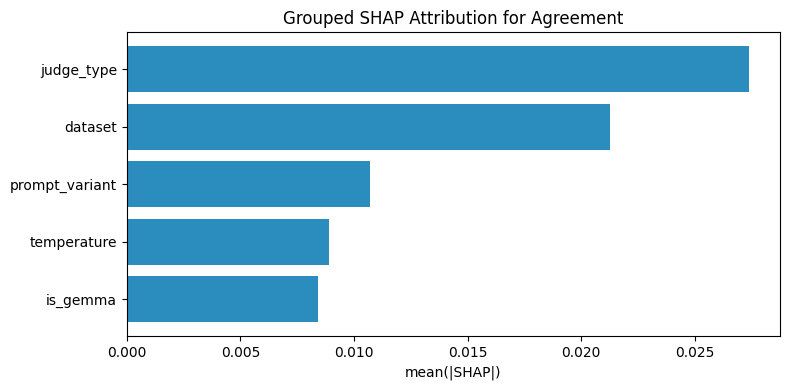

Saved SHAP figure: /home/snt/projects_lujun/LLMJudgeTempCausal/output/shap_grouped_importance_qwen_gemma.png
Saved SHAP table : /home/snt/projects_lujun/LLMJudgeTempCausal/output/shap_grouped_importance_qwen_gemma.csv


In [4]:
try:
    import shap
    SHAP_OK = True
except Exception as e:
    SHAP_OK = False
    print("Cannot import shap:", repr(e))
    print("Install with: pip install shap")

if SHAP_OK:
    attr_df = df_all[["agreement", "is_gemma", "dataset", "judge_type", "prompt_variant", "temperature"]].dropna().copy()

    y = attr_df["agreement"].astype(float)
    X = attr_df[["is_gemma", "dataset", "judge_type", "prompt_variant", "temperature"]]

    cat_cols = ["dataset", "judge_type", "prompt_variant"]
    num_cols = ["is_gemma", "temperature"]

    preproc = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
            ("num", "passthrough", num_cols),
        ]
    )

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        min_samples_leaf=15,
        n_jobs=-1,
    )

    pipe = Pipeline([("prep", preproc), ("rf", model)])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print("Agreement model R^2:", round(r2_score(y_test, y_pred), 4))

    X_test_enc = pipe.named_steps["prep"].transform(X_test)
    feature_names = pipe.named_steps["prep"].get_feature_names_out()

    sample_n = min(5000, X_test_enc.shape[0])
    idx = np.random.choice(X_test_enc.shape[0], size=sample_n, replace=False)
    X_sample = X_test_enc[idx]

    explainer = shap.TreeExplainer(pipe.named_steps["rf"])
    shap_values = explainer.shap_values(X_sample)

    mean_abs = np.abs(shap_values).mean(axis=0)
    shap_imp = pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs})
    shap_imp = shap_imp.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

    def collapse_feature(name: str) -> str:
        if name.startswith("cat__dataset_"):
            return "dataset"
        if name.startswith("cat__judge_type_"):
            return "judge_type"
        if name.startswith("cat__prompt_variant_"):
            return "prompt_variant"
        if name.startswith("num__is_gemma"):
            return "is_gemma"
        if name.startswith("num__temperature"):
            return "temperature"
        return name

    shap_imp["group"] = shap_imp["feature"].map(collapse_feature)
    shap_group = shap_imp.groupby("group", as_index=False)["mean_abs_shap"].sum().sort_values("mean_abs_shap", ascending=False)

    print("Top one-hot SHAP features:")
    display(shap_imp.head(20))
    print("\nGrouped SHAP attribution:")
    display(shap_group)

    plt.figure(figsize=(8, 4))
    topk = shap_group.head(8).iloc[::-1]
    plt.barh(topk["group"], topk["mean_abs_shap"], color="#2b8cbe")
    plt.title("Grouped SHAP Attribution for Agreement")
    plt.xlabel("mean(|SHAP|)")
    plt.tight_layout()
    shap_path = ARTIFACT_DIR / "shap_grouped_importance_qwen_gemma.png"
    plt.savefig(shap_path, dpi=220, bbox_inches="tight")
    plt.show()

    shap_csv_path = ARTIFACT_DIR / "shap_grouped_importance_qwen_gemma.csv"
    shap_group.to_csv(shap_csv_path, index=False)
    print("Saved SHAP figure:", shap_path)
    print("Saved SHAP table :", shap_csv_path)

## Optional Extensions

- 用 `DoWhy` 做 refuter（placebo / subset）。
- 用 `econml` 估计 CATE 并按子群体报告。
- 对 `error_rate` 和 `consistency_1flip` 也做独立 SHAP 归因模型。

## Extension A: DoWhy Refuters

对已估计的因果效应做稳健性检验：
- Placebo Treatment Refuter
- Data Subset Refuter

这里分别在 `agreement`（行级）和 `consistency_1flip`（题级）上运行。

In [5]:
from dowhy import CausalModel


def _extract_refuter_pvalue(ref_obj) -> float:
    rr = getattr(ref_obj, "refutation_result", None)
    if isinstance(rr, dict):
        pv = rr.get("p_value", np.nan)
        if isinstance(pv, (list, tuple, np.ndarray)):
            pv = pv[0] if len(pv) > 0 else np.nan
        try:
            return float(pv)
        except Exception:
            return np.nan
    pv = getattr(ref_obj, "p_value", np.nan)
    try:
        return float(pv)
    except Exception:
        return np.nan


def run_dowhy_refuters(
    data: pd.DataFrame,
    outcome: str,
    treatment: str = "is_gemma",
    controls: list[str] = CONTROL_COLS,
    max_n: int = 120_000,
    random_state: int = 42,
) -> tuple[pd.DataFrame, float]:
    cols = [outcome, treatment, *controls]
    tmp = data[cols].dropna().copy()

    if len(tmp) > max_n:
        tmp = tmp.sample(max_n, random_state=random_state)

    cat_cols = [c for c in controls if str(tmp[c].dtype) == "object" or "category" in str(tmp[c].dtype)]
    tmp_enc = pd.get_dummies(tmp, columns=cat_cols, drop_first=True)

    common_causes = [c for c in tmp_enc.columns if c not in [outcome, treatment]]

    model = CausalModel(
        data=tmp_enc,
        treatment=treatment,
        outcome=outcome,
        common_causes=common_causes,
    )

    estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(estimand, method_name="backdoor.linear_regression")

    rows = []
    refuter_specs = [
        ("placebo_treatment_refuter", {"placebo_type": "permute", "num_simulations": 30}),
        ("data_subset_refuter", {"subset_fraction": 0.8, "num_simulations": 30}),
    ]

    for method_name, kwargs in refuter_specs:
        try:
            ref = model.refute_estimate(estimand, estimate, method_name=method_name, **kwargs)
        except TypeError:
            ref = model.refute_estimate(estimand, estimate, method_name=method_name)

        rows.append(
            {
                "outcome": outcome,
                "method": method_name,
                "n": int(len(tmp_enc)),
                "estimate": float(getattr(estimate, "value", np.nan)),
                "new_effect": float(getattr(ref, "new_effect", np.nan)) if pd.notna(getattr(ref, "new_effect", np.nan)) else np.nan,
                "p_value": _extract_refuter_pvalue(ref),
                "summary": str(ref),
            }
        )

    return pd.DataFrame(rows), float(getattr(estimate, "value", np.nan))


dowhy_tables = []

# Row-level outcome
ref_agreement, agreement_est = run_dowhy_refuters(df_all, outcome="agreement", max_n=120_000)
dowhy_tables.append(ref_agreement)

# Question-level outcome
ref_consistency, consistency_est = run_dowhy_refuters(df_cons, outcome="consistency_1flip", max_n=40_000)
dowhy_tables.append(ref_consistency)

dowhy_refuter_results = pd.concat(dowhy_tables, ignore_index=True)

print("Base estimates (DoWhy linear adjustment):")
print("- agreement:", round(agreement_est, 6))
print("- consistency_1flip:", round(consistency_est, 6))
print("\nRefuter results:")
display(dowhy_refuter_results[["outcome", "method", "estimate", "new_effect", "p_value", "n"]])

dowhy_refuter_path = ARTIFACT_DIR / "dowhy_refuters_qwen_gemma.csv"
dowhy_refuter_results.to_csv(dowhy_refuter_path, index=False)
print("Saved:", dowhy_refuter_path)

Base estimates (DoWhy linear adjustment):
- agreement: -0.009969
- consistency_1flip: 0.052989

Refuter results:


,outcome,method,estimate,new_effect,p_value,n
0,agreement,placebo_treatment_refuter,-0.009969,0.000328,0.450237,120000
1,agreement,data_subset_refuter,-0.009969,-0.009956,0.496536,120000
2,consistency_1flip,placebo_treatment_refuter,0.052989,0.000351,0.416813,35825
3,consistency_1flip,data_subset_refuter,0.052989,0.053055,0.474311,35825


Saved: /home/snt/projects_lujun/LLMJudgeTempCausal/output/dowhy_refuters_qwen_gemma.csv


## Extension B: EconML CATE (with subgroup report)

使用 `LinearDML` 估计个体化效应（CATE），并按：
- dataset
- judge_type
- prompt_variant
- temperature 区间

输出 ATE 与子群体 CATE 汇总表。

In [6]:
from econml.dml import LinearDML
from sklearn.ensemble import RandomForestClassifier


def run_econml_cate(
    data: pd.DataFrame,
    outcome: str,
    treatment: str = "is_gemma",
    controls: list[str] = CONTROL_COLS,
    max_n: int = 120_000,
    random_state: int = 42,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    cols = [outcome, treatment, *controls]
    tmp = data[cols].dropna().copy()

    if len(tmp) > max_n:
        tmp = tmp.sample(max_n, random_state=random_state)

    tmp = tmp.reset_index(drop=True)

    X = pd.get_dummies(
        tmp[controls],
        columns=["dataset", "judge_type", "prompt_variant"],
        drop_first=False,
    )
    X = X.apply(pd.to_numeric, errors="coerce").fillna(0.0)

    Y = tmp[outcome].astype(float).to_numpy()
    T = tmp[treatment].astype(int).to_numpy()

    dml = LinearDML(
        model_y=RandomForestRegressor(
            n_estimators=140,
            min_samples_leaf=25,
            random_state=random_state,
            n_jobs=-1,
        ),
        model_t=RandomForestClassifier(
            n_estimators=140,
            min_samples_leaf=25,
            random_state=random_state,
            n_jobs=-1,
        ),
        discrete_treatment=True,
        cv=3,
        random_state=random_state,
    )

    dml.fit(Y=Y, T=T, X=X)
    cate_hat = dml.effect(X)

    ate = float(np.mean(cate_hat))
    ate_se = float(np.std(cate_hat, ddof=1) / math.sqrt(len(cate_hat))) if len(cate_hat) > 1 else 0.0
    ate_lo, ate_hi = _ci95(ate, ate_se)

    summary = pd.DataFrame(
        [
            {
                "outcome": outcome,
                "n": int(len(tmp)),
                "ate": ate,
                "ate_se": ate_se,
                "ci_low": ate_lo,
                "ci_high": ate_hi,
            }
        ]
    )

    detail = tmp.copy()
    detail["cate_hat"] = cate_hat

    subgroup_rows = []
    for col in ["dataset", "judge_type", "prompt_variant"]:
        g = (
            detail.groupby(col)["cate_hat"]
            .agg(["mean", "std", "count"])
            .reset_index()
            .rename(columns={col: "group_value", "mean": "cate_mean", "std": "cate_std", "count": "n"})
        )
        g.insert(0, "group", col)
        subgroup_rows.append(g)

    detail["temp_bin"] = pd.cut(
        detail["temperature"],
        bins=[-np.inf, 0.3, 0.75, 1.25, 1.75, 2.5, np.inf],
        labels=["<=0.3", "0.3-0.75", "0.75-1.25", "1.25-1.75", "1.75-2.5", ">2.5"],
    )
    g_temp = (
        detail.groupby("temp_bin")["cate_hat"]
        .agg(["mean", "std", "count"])
        .reset_index()
        .rename(columns={"temp_bin": "group_value", "mean": "cate_mean", "std": "cate_std", "count": "n"})
    )
    g_temp.insert(0, "group", "temperature_bin")
    subgroup_rows.append(g_temp)

    subgroup = pd.concat(subgroup_rows, ignore_index=True)

    return summary, subgroup, detail


econml_summary_agreement, econml_subgroup_agreement, econml_detail_agreement = run_econml_cate(
    df_all,
    outcome="agreement",
    max_n=120_000,
)

econml_summary_consistency, econml_subgroup_consistency, econml_detail_consistency = run_econml_cate(
    df_cons,
    outcome="consistency_1flip",
    max_n=40_000,
)

econml_summary = pd.concat([econml_summary_agreement, econml_summary_consistency], ignore_index=True)
econml_subgroup = pd.concat(
    [
        econml_subgroup_agreement.assign(outcome="agreement"),
        econml_subgroup_consistency.assign(outcome="consistency_1flip"),
    ],
    ignore_index=True,
)

print("EconML ATE summary:")
display(econml_summary)

print("\nEconML subgroup CATE (sample):")
display(econml_subgroup.head(30))

econml_summary_path = ARTIFACT_DIR / "econml_cate_summary_qwen_gemma.csv"
econml_subgroup_path = ARTIFACT_DIR / "econml_cate_subgroup_qwen_gemma.csv"
econml_summary.to_csv(econml_summary_path, index=False)
econml_subgroup.to_csv(econml_subgroup_path, index=False)

print("Saved:", econml_summary_path)
print("Saved:", econml_subgroup_path)

/home/snt/projects_lujun/LLMJudgeTempCausal/.venv/lib/python3.11/site-packages/econml/sklearn_extensions/linear_model.py:1815: UserWarning: Co-variance matrix is underdetermined. Inference will be invalid!
  warnings.warn("Co-variance matrix is underdetermined. Inference will be invalid!")


EconML ATE summary:


/home/snt/projects_lujun/LLMJudgeTempCausal/.venv/lib/python3.11/site-packages/econml/sklearn_extensions/linear_model.py:1815: UserWarning: Co-variance matrix is underdetermined. Inference will be invalid!
  warnings.warn("Co-variance matrix is underdetermined. Inference will be invalid!")


,outcome,n,ate,ate_se,ci_low,ci_high
0,agreement,120000,-0.009071,0.000113,-0.009293,-0.008849
1,consistency_1flip,35825,0.052896,0.000208,0.052489,0.053304



EconML subgroup CATE (sample):


,group,group_value,cate_mean,cate_std,n,outcome
0,dataset,mmlu_pro,0.016807,0.035693,34855,agreement
1,dataset,mt_bench_human_judgments,-0.019665,0.035494,85145,agreement
2,judge_type,pairwise,-0.007952,0.022168,39819,agreement
3,judge_type,reference_guided,0.030425,0.022248,39532,agreement
4,judge_type,single_answer,-0.048578,0.022331,40649,agreement
5,prompt_variant,baseline,-0.014233,0.038914,62260,agreement
6,prompt_variant,cot,-0.003505,0.038782,57740,agreement
7,temperature_bin,<=0.3,-0.027062,0.037024,20627,agreement
8,temperature_bin,0.3-0.75,-0.020285,0.036859,20383,agreement
9,temperature_bin,0.75-1.25,-0.012979,0.036807,20328,agreement


Saved: /home/snt/projects_lujun/LLMJudgeTempCausal/output/econml_cate_summary_qwen_gemma.csv
Saved: /home/snt/projects_lujun/LLMJudgeTempCausal/output/econml_cate_subgroup_qwen_gemma.csv


## Extension C: Additional SHAP Attribution

对以下两个 outcome 做独立 SHAP 分析：
- `error_rate`（行级）
- `consistency_1flip`（题级）

输出每个 outcome 的 grouped SHAP 表和图。

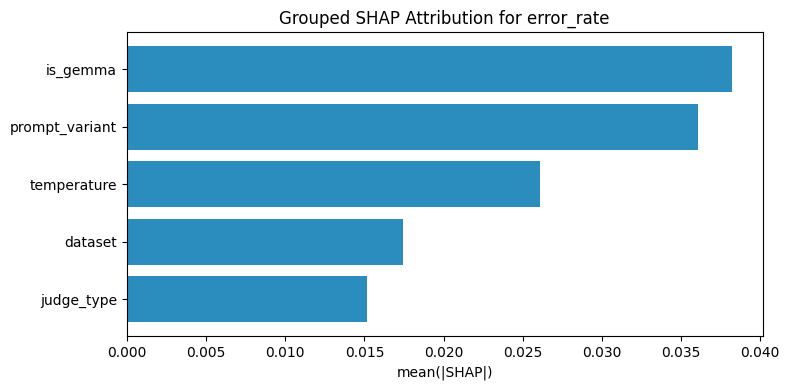

[error_rate] R^2 = 0.1943
Saved: /home/snt/projects_lujun/LLMJudgeTempCausal/output/shap_grouped_importance_error_rate_qwen_gemma.png
Saved: /home/snt/projects_lujun/LLMJudgeTempCausal/output/shap_grouped_importance_error_rate_qwen_gemma.csv


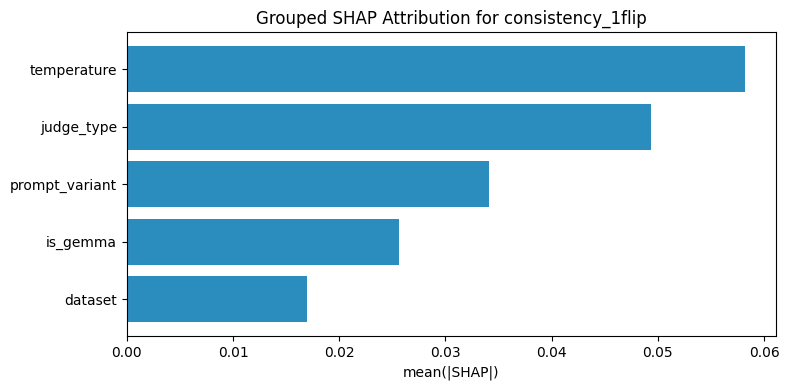

[consistency_1flip] R^2 = 0.1995
Saved: /home/snt/projects_lujun/LLMJudgeTempCausal/output/shap_grouped_importance_consistency_qwen_gemma.png
Saved: /home/snt/projects_lujun/LLMJudgeTempCausal/output/shap_grouped_importance_consistency_qwen_gemma.csv

Grouped SHAP summary (error_rate):


,group,mean_abs_shap
0,is_gemma,0.038231
1,prompt_variant,0.036095
2,temperature,0.026114
3,dataset,0.017455
4,judge_type,0.015174



Grouped SHAP summary (consistency_1flip):


,group,mean_abs_shap
0,temperature,0.058218
1,judge_type,0.049379
2,prompt_variant,0.034097
3,is_gemma,0.025601
4,dataset,0.016977



Model fit summary:


,outcome,r2
0,error_rate,0.194261
1,consistency_1flip,0.199487


Saved: /home/snt/projects_lujun/LLMJudgeTempCausal/output/shap_extra_model_fit_qwen_gemma.csv


In [7]:
try:
    import shap
except Exception as e:
    raise RuntimeError(f"shap is required for this extension: {e}")


def run_grouped_shap(
    data: pd.DataFrame,
    outcome: str,
    artifact_tag: str,
    max_n: int,
    random_state: int = 42,
    shap_sample_n: int = 5000,
) -> tuple[pd.DataFrame, float]:
    tmp = data[[outcome, "is_gemma", "dataset", "judge_type", "prompt_variant", "temperature"]].dropna().copy()

    if len(tmp) > max_n:
        tmp = tmp.sample(max_n, random_state=random_state)

    y = tmp[outcome].astype(float)
    X = tmp[["is_gemma", "dataset", "judge_type", "prompt_variant", "temperature"]]

    cat_cols = ["dataset", "judge_type", "prompt_variant"]
    num_cols = ["is_gemma", "temperature"]

    preproc = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
            ("num", "passthrough", num_cols),
        ]
    )

    model = RandomForestRegressor(
        n_estimators=260,
        random_state=random_state,
        min_samples_leaf=15,
        n_jobs=-1,
    )

    pipe = Pipeline([("prep", preproc), ("rf", model)])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=random_state)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    r2 = float(r2_score(y_test, y_pred))

    X_test_enc = pipe.named_steps["prep"].transform(X_test)
    feature_names = pipe.named_steps["prep"].get_feature_names_out()

    n_shap = min(shap_sample_n, X_test_enc.shape[0])
    rng = np.random.default_rng(random_state)
    idx = rng.choice(X_test_enc.shape[0], size=n_shap, replace=False)
    X_sample = X_test_enc[idx]

    explainer = shap.TreeExplainer(pipe.named_steps["rf"])
    shap_values = explainer.shap_values(X_sample)

    mean_abs = np.abs(shap_values).mean(axis=0)
    shap_imp = pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs})
    shap_imp = shap_imp.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

    def collapse_feature(name: str) -> str:
        if name.startswith("cat__dataset_"):
            return "dataset"
        if name.startswith("cat__judge_type_"):
            return "judge_type"
        if name.startswith("cat__prompt_variant_"):
            return "prompt_variant"
        if name.startswith("num__is_gemma"):
            return "is_gemma"
        if name.startswith("num__temperature"):
            return "temperature"
        return name

    shap_imp["group"] = shap_imp["feature"].map(collapse_feature)
    shap_group = (
        shap_imp.groupby("group", as_index=False)["mean_abs_shap"]
        .sum()
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )

    plt.figure(figsize=(8, 4))
    topk = shap_group.head(8).iloc[::-1]
    plt.barh(topk["group"], topk["mean_abs_shap"], color="#2b8cbe")
    plt.title(f"Grouped SHAP Attribution for {outcome}")
    plt.xlabel("mean(|SHAP|)")
    plt.tight_layout()

    fig_path = ARTIFACT_DIR / f"shap_grouped_importance_{artifact_tag}.png"
    csv_path = ARTIFACT_DIR / f"shap_grouped_importance_{artifact_tag}.csv"

    plt.savefig(fig_path, dpi=220, bbox_inches="tight")
    plt.show()

    shap_group.to_csv(csv_path, index=False)

    print(f"[{outcome}] R^2 = {r2:.4f}")
    print("Saved:", fig_path)
    print("Saved:", csv_path)

    return shap_group, r2


shap_error_group, shap_error_r2 = run_grouped_shap(
    data=df_all,
    outcome="error_rate",
    artifact_tag="error_rate_qwen_gemma",
    max_n=180_000,
)

shap_cons_group, shap_cons_r2 = run_grouped_shap(
    data=df_cons,
    outcome="consistency_1flip",
    artifact_tag="consistency_qwen_gemma",
    max_n=40_000,
)

shap_extra_summary = pd.DataFrame(
    [
        {"outcome": "error_rate", "r2": shap_error_r2},
        {"outcome": "consistency_1flip", "r2": shap_cons_r2},
    ]
)

print("\nGrouped SHAP summary (error_rate):")
display(shap_error_group)
print("\nGrouped SHAP summary (consistency_1flip):")
display(shap_cons_group)
print("\nModel fit summary:")
display(shap_extra_summary)

shap_extra_summary_path = ARTIFACT_DIR / "shap_extra_model_fit_qwen_gemma.csv"
shap_extra_summary.to_csv(shap_extra_summary_path, index=False)
print("Saved:", shap_extra_summary_path)

## Final Findings

本节自动汇总：
- 主效应估计表
- Refuter 稳健性结果
- CATE 异质性摘要
- SHAP 归因摘要
- 一段可直接用于论文/报告的结论文本

该部分优先读取 `output/` 下已导出的结果文件，因此可以独立运行。

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Markdown, display


def resolve_artifact_dir_local() -> Path:
    for cand in ["output", "../output"]:
        p = Path(cand)
        if p.exists():
            return p.resolve()
    raise FileNotFoundError("Could not find output directory")


def load_df_from_memory_or_csv(var_name: str, file_name: str, artifact_dir: Path) -> pd.DataFrame:
    obj = globals().get(var_name, None)
    if isinstance(obj, pd.DataFrame):
        return obj.copy()
    path = artifact_dir / file_name
    if not path.exists():
        raise FileNotFoundError(f"Missing required artifact: {path}")
    return pd.read_csv(path)


artifact_dir_local = globals().get("ARTIFACT_DIR", None)
if artifact_dir_local is None:
    artifact_dir_local = resolve_artifact_dir_local()

row_df_local = load_df_from_memory_or_csv("df_all", "combined_judge_dataset_qwen_gemma.csv", artifact_dir_local)
cons_df_local = load_df_from_memory_or_csv("df_cons", "combined_judge_consistency_qwen_gemma.csv", artifact_dir_local)
causal_summary_local = load_df_from_memory_or_csv("causal_summary", "causal_effects_qwen_vs_gemma.csv", artifact_dir_local)
dowhy_refuter_results_local = load_df_from_memory_or_csv("dowhy_refuter_results", "dowhy_refuters_qwen_gemma.csv", artifact_dir_local)
econml_summary_local = load_df_from_memory_or_csv("econml_summary", "econml_cate_summary_qwen_gemma.csv", artifact_dir_local)
econml_subgroup_local = load_df_from_memory_or_csv("econml_subgroup", "econml_cate_subgroup_qwen_gemma.csv", artifact_dir_local)
shap_agreement_local = load_df_from_memory_or_csv("shap_group", "shap_grouped_importance_qwen_gemma.csv", artifact_dir_local)
shap_error_local = load_df_from_memory_or_csv("shap_error_group", "shap_grouped_importance_error_rate_qwen_gemma.csv", artifact_dir_local)
shap_cons_local = load_df_from_memory_or_csv("shap_cons_group", "shap_grouped_importance_consistency_qwen_gemma.csv", artifact_dir_local)

outcome_label_map = {
    "agreement": "Agreement",
    "consistency_1flip": "Consistency (1-flip)",
    "error_rate": "Error Rate",
}

method_order = ["matched", "regression_ols", "ipw", "aipw"]
main_effects = causal_summary_local.pivot(index="outcome", columns="method", values="ate").reset_index()
main_effects = main_effects[["outcome", *[m for m in method_order if m in main_effects.columns]]]

primary = (
    causal_summary_local.loc[causal_summary_local["method"] == "aipw", ["outcome", "ate", "ci_low", "ci_high"]]
    .rename(columns={"ate": "primary_ate", "ci_low": "primary_ci_low", "ci_high": "primary_ci_high"})
)
main_effects = primary.merge(main_effects, on="outcome", how="left")

spread = causal_summary_local.groupby("outcome")["ate"].agg(lambda s: float(s.max() - s.min())).rename("method_spread")
main_effects = main_effects.merge(spread, on="outcome", how="left")
main_effects["Outcome"] = main_effects["outcome"].map(outcome_label_map)
main_effects["Primary 95% CI"] = main_effects.apply(lambda r: f"[{r['primary_ci_low']:.4f}, {r['primary_ci_high']:.4f}]", axis=1)
main_effects["Primary Effect (pp)"] = main_effects["primary_ate"] * 100.0


def interpret_effect(outcome: str, ate: float) -> str:
    magnitude = abs(ate) * 100.0
    if outcome == "agreement":
        return f"Gemma {'improves' if ate > 0 else 'reduces'} agreement by {magnitude:.2f} pp"
    if outcome == "consistency_1flip":
        return f"Gemma {'improves' if ate > 0 else 'reduces'} consistency by {magnitude:.2f} pp"
    if outcome == "error_rate":
        return f"Gemma {'increases' if ate > 0 else 'reduces'} error rate by {magnitude:.2f} pp"
    return f"Effect = {ate:.4f}"


main_effects["Interpretation"] = main_effects.apply(lambda r: interpret_effect(r["outcome"], r["primary_ate"]), axis=1)
main_effects_display = main_effects[
    [
        "Outcome",
        "primary_ate",
        "Primary 95% CI",
        "matched",
        "regression_ols",
        "ipw",
        "aipw",
        "method_spread",
        "Interpretation",
    ]
].rename(
    columns={
        "primary_ate": "Primary ATE (AIPW)",
        "matched": "Matched ATE",
        "regression_ols": "OLS ATE",
        "ipw": "IPW ATE",
        "aipw": "AIPW ATE",
        "method_spread": "ATE Range Across Methods",
    }
)

refuter_table = dowhy_refuter_results_local.copy()
refuter_table["delta_vs_estimate"] = refuter_table["new_effect"] - refuter_table["estimate"]
refuter_table["Outcome"] = refuter_table["outcome"].map(outcome_label_map)
refuter_display = refuter_table[
    ["Outcome", "method", "estimate", "new_effect", "delta_vs_estimate", "p_value", "n"]
].rename(
    columns={
        "method": "Refuter",
        "estimate": "Original Estimate",
        "new_effect": "Refuted Estimate",
        "delta_vs_estimate": "Delta",
        "p_value": "p-value",
    }
)

ate_map = econml_summary_local.set_index("outcome")["ate"].to_dict()
heterogeneity = econml_subgroup_local.copy()
heterogeneity["overall_ate"] = heterogeneity["outcome"].map(ate_map)
heterogeneity["deviation_from_ate"] = heterogeneity["cate_mean"] - heterogeneity["overall_ate"]
heterogeneity["abs_deviation"] = heterogeneity["deviation_from_ate"].abs()
heterogeneity = heterogeneity.dropna(subset=["cate_mean"])
heterogeneity_highlights = (
    heterogeneity.sort_values(["outcome", "abs_deviation"], ascending=[True, False])
    .groupby("outcome", group_keys=False)
    .head(6)
    .reset_index(drop=True)
)
heterogeneity_highlights["Outcome"] = heterogeneity_highlights["outcome"].map(outcome_label_map)
heterogeneity_display = heterogeneity_highlights[
    ["Outcome", "group", "group_value", "cate_mean", "overall_ate", "deviation_from_ate", "n"]
].rename(
    columns={
        "group": "Group",
        "group_value": "Level",
        "cate_mean": "Subgroup CATE",
        "overall_ate": "Overall ATE",
        "deviation_from_ate": "Deviation from Overall",
    }
)

shap_summary = pd.concat(
    [
        shap_agreement_local.assign(outcome="agreement"),
        shap_error_local.assign(outcome="error_rate"),
        shap_cons_local.assign(outcome="consistency_1flip"),
    ],
    ignore_index=True,
)
shap_top = (
    shap_summary.sort_values(["outcome", "mean_abs_shap"], ascending=[True, False])
    .groupby("outcome", group_keys=False)
    .head(5)
    .reset_index(drop=True)
)
shap_top["Outcome"] = shap_top["outcome"].map(outcome_label_map)
shap_display = shap_top[["Outcome", "group", "mean_abs_shap"]].rename(columns={"group": "Feature Group", "mean_abs_shap": "mean(|SHAP|)"})


def top_shap_group(df: pd.DataFrame) -> str:
    if len(df) == 0:
        return "N/A"
    return str(df.sort_values("mean_abs_shap", ascending=False).iloc[0]["group"])


def subgroup_extremes(outcome: str) -> tuple[pd.Series, pd.Series]:
    sub = heterogeneity.loc[heterogeneity["outcome"] == outcome].copy()
    if len(sub) == 0:
        empty = pd.Series({"group": "N/A", "group_value": "N/A", "cate_mean": np.nan})
        return empty, empty
    sub = sub.sort_values("cate_mean")
    return sub.iloc[0], sub.iloc[-1]


agr_low, agr_high = subgroup_extremes("agreement")
con_low, con_high = subgroup_extremes("consistency_1flip")
err_low, err_high = subgroup_extremes("error_rate")

agr_aipw = float(main_effects.loc[main_effects["outcome"] == "agreement", "primary_ate"].iloc[0])
con_aipw = float(main_effects.loc[main_effects["outcome"] == "consistency_1flip", "primary_ate"].iloc[0])
err_aipw = float(main_effects.loc[main_effects["outcome"] == "error_rate", "primary_ate"].iloc[0])

n_rows = int(len(row_df_local))
n_cons = int(len(cons_df_local))

narrative = f"""
### Manuscript-style Conclusion

Using a combined benchmark of {n_rows:,} row-level judge records and {n_cons:,} question-level consistency records, the integrated causal analysis shows a stable trade-off between the two judge families. Under the primary doubly robust AIPW specification, replacing Qwen with Gemma is associated with a {abs(agr_aipw)*100:.2f} percentage-point decrease in agreement, a {abs(con_aipw)*100:.2f} percentage-point {'increase' if con_aipw > 0 else 'decrease'} in run-to-run consistency, and a {abs(err_aipw)*100:.2f} percentage-point {'decrease' if err_aipw < 0 else 'increase'} in error rate. The direction and magnitude are consistent across matched, regression-adjusted, IPW, and AIPW estimators, suggesting that the result is not driven by a single estimation strategy.

Robustness checks with DoWhy further support this interpretation. For both agreement and consistency, placebo-treatment refuters produce near-zero effects, while subset refuters recover estimates that remain close to the original adjusted estimates. This pattern is consistent with a causal signal that is relatively stable to resampling and not easily reproduced by randomized pseudo-treatment assignments.

Heterogeneity analysis with EconML indicates that the treatment effect is not uniform across evaluation settings. For agreement, the most negative subgroup effect appears at {agr_low['group']}={agr_low['group_value']} (CATE={agr_low['cate_mean']:.4f}), whereas the least negative / most positive subgroup appears at {agr_high['group']}={agr_high['group_value']} (CATE={agr_high['cate_mean']:.4f}). For consistency, the weakest subgroup effect appears at {con_low['group']}={con_low['group_value']} (CATE={con_low['cate_mean']:.4f}), while the strongest subgroup effect appears at {con_high['group']}={con_high['group_value']} (CATE={con_high['cate_mean']:.4f}).

Feature-attribution analysis adds a complementary predictive interpretation. Agreement variation is primarily associated with {top_shap_group(shap_agreement_local)}, error-rate variation is primarily associated with {top_shap_group(shap_error_local)}, and consistency variation is primarily associated with {top_shap_group(shap_cons_local)}. Notably, `is_gemma` is the top SHAP driver for error rate and remains a major contributor for consistency, reinforcing the conclusion that the model family itself materially affects output stability and formatting reliability.

Overall, the evidence suggests that Gemma is more robust in formatting and more stable across repeated runs, but this robustness comes with a modest reduction in alignment with the reference winner signal relative to Qwen under the current prompting and temperature settings.
""".strip()

print("Primary effects summary:")
display(main_effects_display)
print("\nRefuter robustness summary:")
display(refuter_display)
print("\nCATE heterogeneity highlights:")
display(heterogeneity_display)
print("\nTop grouped SHAP drivers:")
display(shap_display)

display(Markdown(narrative))

final_table_path = artifact_dir_local / "final_causal_conclusion_table_qwen_gemma.csv"
final_markdown_path = artifact_dir_local / "final_causal_findings_qwen_gemma.md"
main_effects_display.to_csv(final_table_path, index=False)
final_markdown_path.write_text(narrative + "\n", encoding="utf-8")

print("Saved:", final_table_path)
print("Saved:", final_markdown_path)

Primary effects summary:


,Outcome,Primary ATE (AIPW),Primary 95% CI,Matched ATE,OLS ATE,IPW ATE,AIPW ATE,ATE Range Across Methods,Interpretation
0,Agreement,-0.009023,"[-0.0123, -0.0057]",-0.013745,-0.009815,-0.009696,-0.009023,0.004722,Gemma reduces agreement by 0.90 pp
1,Error Rate,-0.075411,"[-0.0767, -0.0742]",-0.075411,-0.075411,-0.075411,-0.075411,0.000000,Gemma reduces error rate by 7.54 pp
2,Consistency (1-flip),0.053061,"[0.0487, 0.0574]",0.052792,0.052989,0.053000,0.053061,0.000269,Gemma improves consistency by 5.31 pp



Refuter robustness summary:


,Outcome,Refuter,Original Estimate,Refuted Estimate,Delta,p-value,n
0,Agreement,placebo_treatment_refuter,-0.009969,0.000328,0.010297,0.450237,120000
1,Agreement,data_subset_refuter,-0.009969,-0.009956,0.000013,0.496536,120000
2,Consistency (1-flip),placebo_treatment_refuter,0.052989,0.000351,-0.052638,0.416813,35825
3,Consistency (1-flip),data_subset_refuter,0.052989,0.053055,0.000066,0.474311,35825



CATE heterogeneity highlights:


,Outcome,Group,Level,Subgroup CATE,Overall ATE,Deviation from Overall,n
0,Agreement,judge_type,single_answer,-0.048578,-0.009071,-0.039506,40649
1,Agreement,judge_type,reference_guided,0.030425,-0.009071,0.039496,39532
2,Agreement,dataset,mmlu_pro,0.016807,-0.009071,0.025878,34855
3,Agreement,temperature_bin,>2.5,0.013205,-0.009071,0.022276,18676
4,Agreement,temperature_bin,<=0.3,-0.027062,-0.009071,-0.017991,20627
5,Agreement,temperature_bin,0.3-0.75,-0.020285,-0.009071,-0.011214,20383
6,Consistency (1-flip),judge_type,single_answer,0.004908,0.052896,-0.047988,11922
7,Consistency (1-flip),judge_type,reference_guided,0.086583,0.052896,0.033687,11974
8,Consistency (1-flip),temperature_bin,>2.5,0.083106,0.052896,0.030210,5959
9,Consistency (1-flip),temperature_bin,<=0.3,0.028849,0.052896,-0.024047,5955



Top grouped SHAP drivers:


,Outcome,Feature Group,mean(|SHAP|)
0,Agreement,judge_type,0.027388
1,Agreement,dataset,0.021273
2,Agreement,prompt_variant,0.010720
3,Agreement,temperature,0.008909
4,Agreement,is_gemma,0.008421
5,Consistency (1-flip),temperature,0.058218
6,Consistency (1-flip),judge_type,0.049379
7,Consistency (1-flip),prompt_variant,0.034097
8,Consistency (1-flip),is_gemma,0.025601
9,Consistency (1-flip),dataset,0.016977


### Manuscript-style Conclusion

Using a combined benchmark of 360,000 row-level judge records and 36,000 question-level consistency records, the integrated causal analysis shows a stable trade-off between the two judge families. Under the primary doubly robust AIPW specification, replacing Qwen with Gemma is associated with a 0.90 percentage-point decrease in agreement, a 5.31 percentage-point increase in run-to-run consistency, and a 7.54 percentage-point decrease in error rate. The direction and magnitude are consistent across matched, regression-adjusted, IPW, and AIPW estimators, suggesting that the result is not driven by a single estimation strategy.

Robustness checks with DoWhy further support this interpretation. For both agreement and consistency, placebo-treatment refuters produce near-zero effects, while subset refuters recover estimates that remain close to the original adjusted estimates. This pattern is consistent with a causal signal that is relatively stable to resampling and not easily reproduced by randomized pseudo-treatment assignments.

Heterogeneity analysis with EconML indicates that the treatment effect is not uniform across evaluation settings. For agreement, the most negative subgroup effect appears at judge_type=single_answer (CATE=-0.0486), whereas the least negative / most positive subgroup appears at judge_type=reference_guided (CATE=0.0304). For consistency, the weakest subgroup effect appears at judge_type=single_answer (CATE=0.0049), while the strongest subgroup effect appears at judge_type=reference_guided (CATE=0.0866).

Feature-attribution analysis adds a complementary predictive interpretation. Agreement variation is primarily associated with judge_type, error-rate variation is primarily associated with is_gemma, and consistency variation is primarily associated with temperature. Notably, `is_gemma` is the top SHAP driver for error rate and remains a major contributor for consistency, reinforcing the conclusion that the model family itself materially affects output stability and formatting reliability.

Overall, the evidence suggests that Gemma is more robust in formatting and more stable across repeated runs, but this robustness comes with a modest reduction in alignment with the reference winner signal relative to Qwen under the current prompting and temperature settings.

Saved: /home/snt/projects_lujun/LLMJudgeTempCausal/output/final_causal_conclusion_table_qwen_gemma.csv
Saved: /home/snt/projects_lujun/LLMJudgeTempCausal/output/final_causal_findings_qwen_gemma.md


## One-Page Summary Figure

本节将主效应、异质性和 SHAP 归因整合到 1 张图里，便于汇报或放进附录。

图中包含：
- 主效应 ATE 与 95% CI
- 最显著的 CATE 异质性子群体
- 三个 outcome 的 grouped SHAP 热图
- 右上角结论摘要框

该单元优先复用前面的内存对象；如果当前内核里没有，也会从 `output/` 读取结果文件。

/tmp/ipykernel_4099532/3509600597.py:211: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.96])


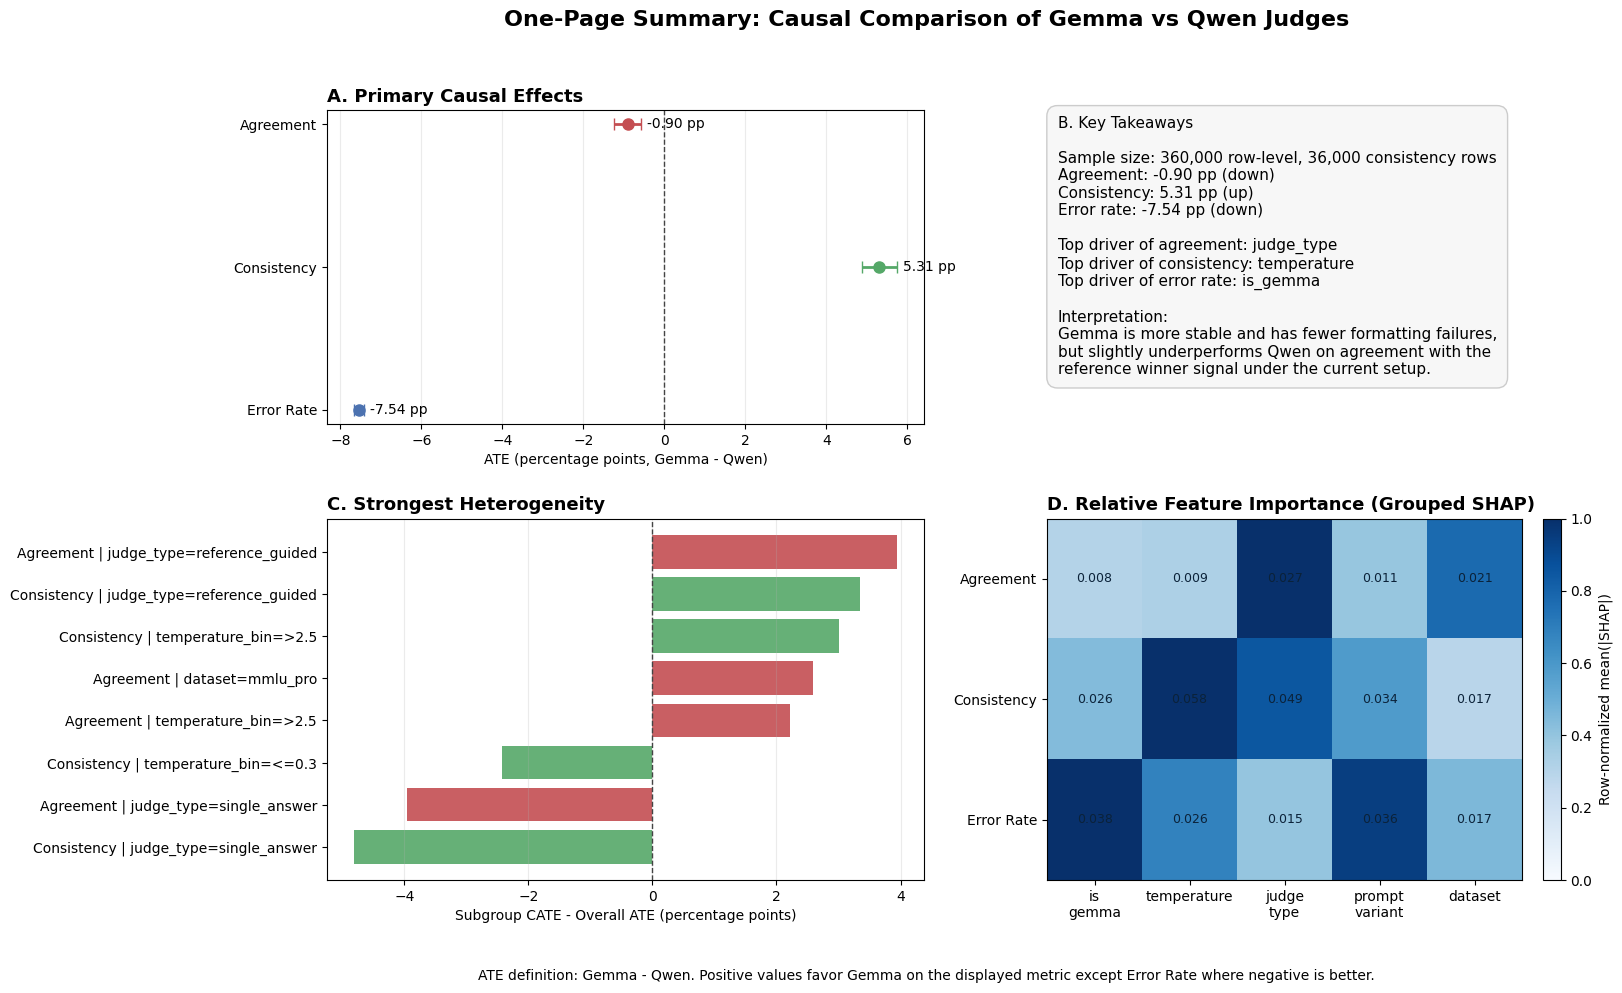

Saved: /home/snt/projects_lujun/LLMJudgeTempCausal/output/one_page_summary_qwen_gemma.png
Saved: /home/snt/projects_lujun/LLMJudgeTempCausal/output/one_page_summary_qwen_gemma.pdf


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec


if "artifact_dir_local" not in globals():
    def resolve_artifact_dir_local() -> Path:
        for cand in ["output", "../output"]:
            p = Path(cand)
            if p.exists():
                return p.resolve()
        raise FileNotFoundError("Could not find output directory")

    def load_df_from_memory_or_csv(var_name: str, file_name: str, artifact_dir: Path) -> pd.DataFrame:
        obj = globals().get(var_name, None)
        if isinstance(obj, pd.DataFrame):
            return obj.copy()
        path = artifact_dir / file_name
        if not path.exists():
            raise FileNotFoundError(f"Missing required artifact: {path}")
        return pd.read_csv(path)

    artifact_dir_local = resolve_artifact_dir_local()
else:
    artifact_dir_local = Path(artifact_dir_local)


causal_summary_plot = globals().get("causal_summary_local", None)
if not isinstance(causal_summary_plot, pd.DataFrame):
    causal_summary_plot = load_df_from_memory_or_csv("causal_summary", "causal_effects_qwen_vs_gemma.csv", artifact_dir_local)

econml_subgroup_plot = globals().get("econml_subgroup_local", None)
if not isinstance(econml_subgroup_plot, pd.DataFrame):
    econml_subgroup_plot = load_df_from_memory_or_csv("econml_subgroup", "econml_cate_subgroup_qwen_gemma.csv", artifact_dir_local)

shap_agreement_plot = globals().get("shap_agreement_local", None)
if not isinstance(shap_agreement_plot, pd.DataFrame):
    shap_agreement_plot = load_df_from_memory_or_csv("shap_group", "shap_grouped_importance_qwen_gemma.csv", artifact_dir_local)

shap_error_plot = globals().get("shap_error_local", None)
if not isinstance(shap_error_plot, pd.DataFrame):
    shap_error_plot = load_df_from_memory_or_csv("shap_error_group", "shap_grouped_importance_error_rate_qwen_gemma.csv", artifact_dir_local)

shap_cons_plot = globals().get("shap_cons_local", None)
if not isinstance(shap_cons_plot, pd.DataFrame):
    shap_cons_plot = load_df_from_memory_or_csv("shap_cons_group", "shap_grouped_importance_consistency_qwen_gemma.csv", artifact_dir_local)

row_df_plot = globals().get("row_df_local", None)
if not isinstance(row_df_plot, pd.DataFrame):
    row_df_plot = load_df_from_memory_or_csv("df_all", "combined_judge_dataset_qwen_gemma.csv", artifact_dir_local)

cons_df_plot = globals().get("cons_df_local", None)
if not isinstance(cons_df_plot, pd.DataFrame):
    cons_df_plot = load_df_from_memory_or_csv("df_cons", "combined_judge_consistency_qwen_gemma.csv", artifact_dir_local)

outcome_order = ["agreement", "consistency_1flip", "error_rate"]
outcome_label_map_plot = {
    "agreement": "Agreement",
    "consistency_1flip": "Consistency",
    "error_rate": "Error Rate",
}
outcome_color_map = {
    "agreement": "#c44e52",
    "consistency_1flip": "#55a868",
    "error_rate": "#4c72b0",
}

primary_plot = (
    causal_summary_plot.loc[causal_summary_plot["method"] == "aipw", ["outcome", "ate", "ci_low", "ci_high"]]
    .set_index("outcome")
    .reindex(outcome_order)
    .reset_index()
)
primary_plot["label"] = primary_plot["outcome"].map(outcome_label_map_plot)

ate_map_plot = primary_plot.set_index("outcome")["ate"].to_dict()
heterogeneity_plot = econml_subgroup_plot.copy()
heterogeneity_plot = heterogeneity_plot.dropna(subset=["cate_mean"]).copy()
heterogeneity_plot["overall_ate"] = heterogeneity_plot["outcome"].map(ate_map_plot)
heterogeneity_plot["deviation"] = heterogeneity_plot["cate_mean"] - heterogeneity_plot["overall_ate"]
heterogeneity_plot["abs_deviation"] = heterogeneity_plot["deviation"].abs()
heterogeneity_plot["label"] = heterogeneity_plot.apply(
    lambda r: f"{outcome_label_map_plot.get(r['outcome'], r['outcome'])} | {r['group']}={r['group_value']}", axis=1
)
heterogeneity_top = (
    heterogeneity_plot.sort_values("abs_deviation", ascending=False)
    .head(8)
    .sort_values("deviation")
    .reset_index(drop=True)
)

shap_matrix = pd.concat(
    [
        shap_agreement_plot.assign(outcome="agreement"),
        shap_error_plot.assign(outcome="error_rate"),
        shap_cons_plot.assign(outcome="consistency_1flip"),
    ],
    ignore_index=True,
)
shap_matrix = shap_matrix.pivot(index="outcome", columns="group", values="mean_abs_shap")
shap_cols = [c for c in ["is_gemma", "temperature", "judge_type", "prompt_variant", "dataset"] if c in shap_matrix.columns]
shap_matrix = shap_matrix.reindex(index=outcome_order, columns=shap_cols)
shap_matrix_display = shap_matrix.copy()
shap_matrix_norm = shap_matrix.div(shap_matrix.max(axis=1), axis=0).fillna(0.0)

n_rows_plot = int(len(row_df_plot))
n_cons_plot = int(len(cons_df_plot))

agree_effect = float(primary_plot.loc[primary_plot["outcome"] == "agreement", "ate"].iloc[0])
cons_effect = float(primary_plot.loc[primary_plot["outcome"] == "consistency_1flip", "ate"].iloc[0])
error_effect = float(primary_plot.loc[primary_plot["outcome"] == "error_rate", "ate"].iloc[0])

agree_driver = shap_agreement_plot.sort_values("mean_abs_shap", ascending=False).iloc[0]["group"]
error_driver = shap_error_plot.sort_values("mean_abs_shap", ascending=False).iloc[0]["group"]
cons_driver = shap_cons_plot.sort_values("mean_abs_shap", ascending=False).iloc[0]["group"]

fig = plt.figure(figsize=(16, 10), constrained_layout=False)
gs = GridSpec(2, 2, figure=fig, height_ratios=[1.0, 1.15], width_ratios=[1.15, 1.0], hspace=0.28, wspace=0.22)

ax_effect = fig.add_subplot(gs[0, 0])
ax_text = fig.add_subplot(gs[0, 1])
ax_hetero = fig.add_subplot(gs[1, 0])
ax_shap = fig.add_subplot(gs[1, 1])

# Panel A: primary causal effects
for idx, row in primary_plot.iloc[::-1].reset_index(drop=True).iterrows():
    y = idx
    color = outcome_color_map[row["outcome"]]
    ax_effect.errorbar(
        x=row["ate"] * 100,
        y=y,
        xerr=[[ (row["ate"] - row["ci_low"]) * 100 ], [ (row["ci_high"] - row["ate"]) * 100 ]],
        fmt="o",
        color=color,
        ecolor=color,
        elinewidth=2,
        capsize=4,
        markersize=8,
    )
    ax_effect.text(row["ci_high"] * 100 + 0.15, y, f"{row['ate']*100:.2f} pp", va="center", fontsize=10)

ax_effect.axvline(0, color="#444444", linestyle="--", linewidth=1)
ax_effect.set_yticks(range(len(primary_plot)))
ax_effect.set_yticklabels(primary_plot.iloc[::-1]["label"].tolist())
ax_effect.set_xlabel("ATE (percentage points, Gemma - Qwen)")
ax_effect.set_title("A. Primary Causal Effects", loc="left", fontsize=13, fontweight="bold")
ax_effect.grid(axis="x", alpha=0.25)

# Panel B: takeaways text
ax_text.axis("off")
text_lines = [
    "B. Key Takeaways",
    "",
    f"Sample size: {n_rows_plot:,} row-level, {n_cons_plot:,} consistency rows",
    f"Agreement: {agree_effect*100:.2f} pp ({'down' if agree_effect < 0 else 'up'})",
    f"Consistency: {cons_effect*100:.2f} pp ({'up' if cons_effect > 0 else 'down'})",
    f"Error rate: {error_effect*100:.2f} pp ({'down' if error_effect < 0 else 'up'})",
    "",
    f"Top driver of agreement: {agree_driver}",
    f"Top driver of consistency: {cons_driver}",
    f"Top driver of error rate: {error_driver}",
    "",
    "Interpretation:",
    "Gemma is more stable and has fewer formatting failures,",
    "but slightly underperforms Qwen on agreement with the",
    "reference winner signal under the current setup.",
]
ax_text.text(
    0.02,
    0.98,
    "\n".join(text_lines),
    va="top",
    ha="left",
    fontsize=11,
    bbox={"boxstyle": "round,pad=0.7", "facecolor": "#f7f7f7", "edgecolor": "#cccccc"},
)

# Panel C: heterogeneity
if len(heterogeneity_top) > 0:
    colors = [outcome_color_map.get(x, "#888888") for x in heterogeneity_top["outcome"]]
    ax_hetero.barh(heterogeneity_top["label"], heterogeneity_top["deviation"] * 100, color=colors, alpha=0.9)
    ax_hetero.axvline(0, color="#444444", linestyle="--", linewidth=1)
    ax_hetero.set_xlabel("Subgroup CATE - Overall ATE (percentage points)")
    ax_hetero.set_title("C. Strongest Heterogeneity", loc="left", fontsize=13, fontweight="bold")
    ax_hetero.grid(axis="x", alpha=0.25)
else:
    ax_hetero.axis("off")
    ax_hetero.text(0.5, 0.5, "No heterogeneity results available", ha="center", va="center")

# Panel D: grouped SHAP heatmap
im = ax_shap.imshow(shap_matrix_norm.to_numpy(), cmap="Blues", aspect="auto", vmin=0, vmax=1)
ax_shap.set_xticks(np.arange(len(shap_matrix_norm.columns)))
ax_shap.set_xticklabels([c.replace("_", "\n") for c in shap_matrix_norm.columns], rotation=0)
ax_shap.set_yticks(np.arange(len(shap_matrix_norm.index)))
ax_shap.set_yticklabels([outcome_label_map_plot.get(x, x) for x in shap_matrix_norm.index])
ax_shap.set_title("D. Relative Feature Importance (Grouped SHAP)", loc="left", fontsize=13, fontweight="bold")

for i in range(shap_matrix_norm.shape[0]):
    for j in range(shap_matrix_norm.shape[1]):
        val = shap_matrix_display.iloc[i, j]
        ax_shap.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=9, color="#0b2239")

cbar = fig.colorbar(im, ax=ax_shap, fraction=0.046, pad=0.04)
cbar.set_label("Row-normalized mean(|SHAP|)")

fig.suptitle("One-Page Summary: Causal Comparison of Gemma vs Qwen Judges", fontsize=16, fontweight="bold", y=0.98)
fig.text(0.5, 0.01, "ATE definition: Gemma - Qwen. Positive values favor Gemma on the displayed metric except Error Rate where negative is better.", ha="center", fontsize=10)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])

summary_fig_path = artifact_dir_local / "one_page_summary_qwen_gemma.png"
summary_pdf_path = artifact_dir_local / "one_page_summary_qwen_gemma.pdf"
plt.savefig(summary_fig_path, dpi=240, bbox_inches="tight")
plt.savefig(summary_pdf_path, bbox_inches="tight")
plt.show()

print("Saved:", summary_fig_path)
print("Saved:", summary_pdf_path)